# Exploratory Data Analysis: 

This notebook is only for Exploratory Data Analysis

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scripts import data_cleaning

Final shape: (15272, 39)
       Season Ending Year           Age         Games  Games Started  \
count        15272.000000  15272.000000  15272.000000   15272.000000   
mean          2004.518007     26.806181     61.912913      31.707307   
std             13.108267      4.057154     18.105578      29.398076   
min           1980.000000     18.000000      4.000000       0.000000   
25%           1993.750000     24.000000     50.000000       4.000000   
50%           2006.000000     26.000000     67.000000      22.000000   
75%           2016.000000     30.000000     78.000000      61.000000   
max           2025.000000     43.000000     84.000000      83.000000   

       Minutes per game  FGA per game  2PA per game  3PA per game  \
count      1.527200e+04  1.527200e+04  1.527200e+04  1.527200e+04   
mean       5.048054e-17  6.164675e-18 -3.431281e-17  7.909394e-18   
std        9.985583e-01  9.985583e-01  9.985583e-01  9.985583e-01   
min       -1.899350e+00 -1.772114e+00 -1.763868e+0

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

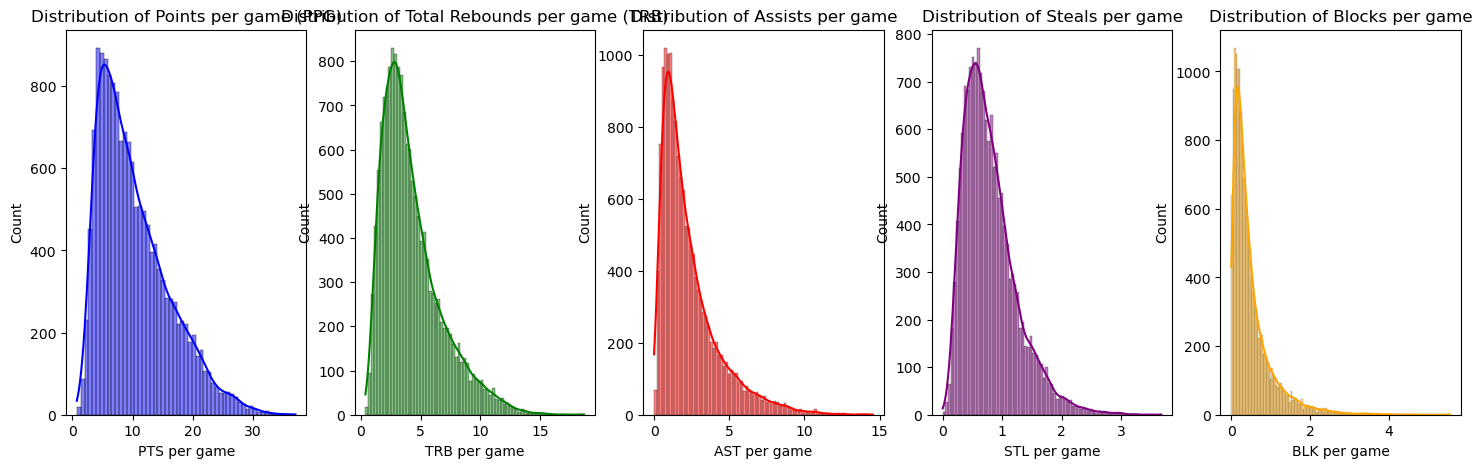

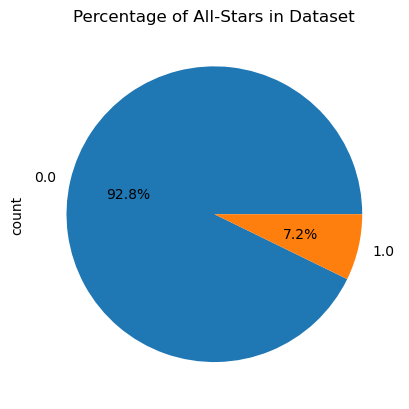

In [2]:
# Look at the distribution of Points
df = data_cleaning.df_eda

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
sns.histplot(data =df, x='PTS per game', kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Points per game (PPG)')

sns.histplot(data =df, x='TRB per game', kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Total Rebounds per game (TRB)')

sns.histplot(data =df, x='AST per game', kde=True, ax=axes[2], color='red')
axes[2].set_title('Distribution of Assists per game')

sns.histplot(data =df, x='STL per game', kde=True, ax=axes[3], color='purple')
axes[3].set_title('Distribution of Steals per game')

sns.histplot(data =df, x='BLK per game', kde=True, ax=axes[4], color='orange')
axes[4].set_title('Distribution of Blocks per game')

plt.show()

df['All Star'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentage of All-Stars in Dataset')
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a

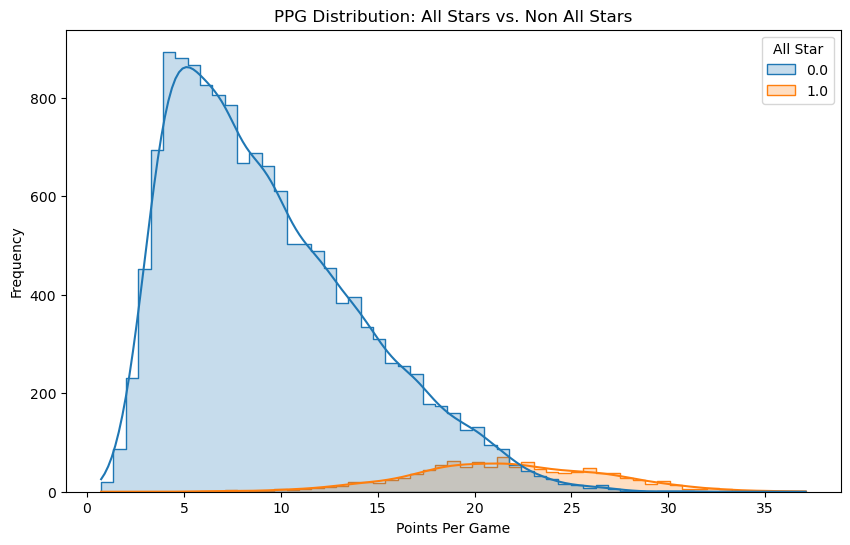

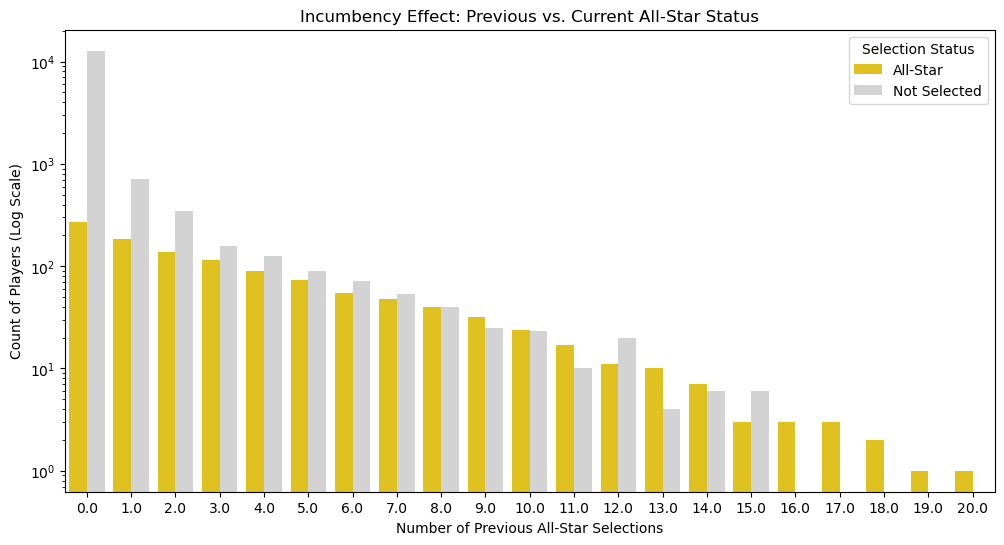

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


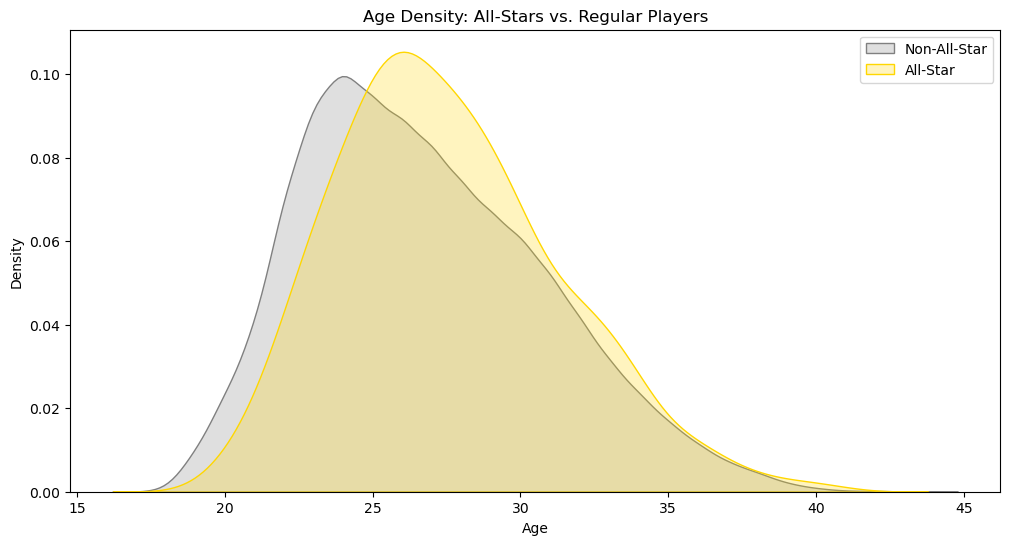

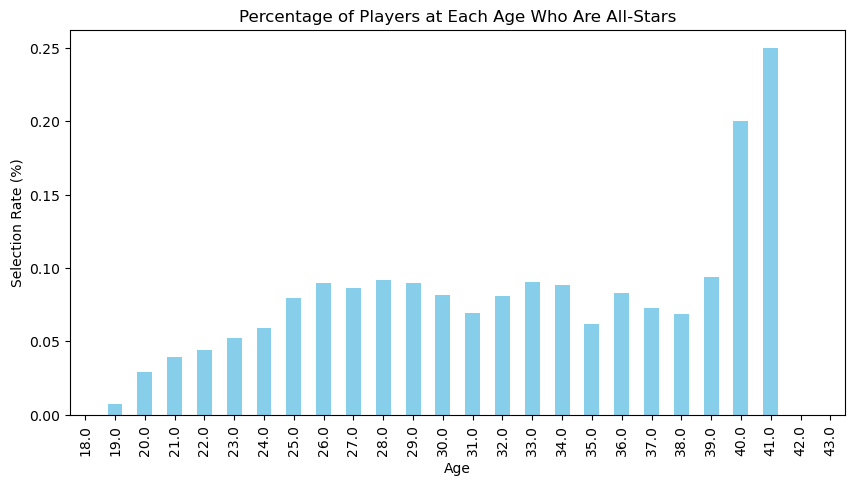

In [3]:
plt.figure(figsize=(10, 6))
# 'hue' splits the data by the All-Star column
sns.histplot(data=df, x='PTS per game', hue='All Star', kde=True, element="step")

plt.title('PPG Distribution: All Stars vs. Non All Stars')
plt.xlabel('Points Per Game')
plt.ylabel('Frequency')
plt.show()


#  temporary column for plotting with string labels
df['Selection Status'] = df['All Star'].map({0: 'Not Selected', 1: 'All-Star'})
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='Prev All Stars', hue='Selection Status', 
              palette={'Not Selected': 'lightgrey', 'All-Star': 'gold'})

plt.yscale('log')
plt.title('Incumbency Effect: Previous vs. Current All-Star Status')
plt.xlabel('Number of Previous All-Star Selections')
plt.ylabel('Count of Players (Log Scale)')

# remove the temporary column after plotting
df.drop('Selection Status', axis=1, inplace=True)

plt.show()


plt.figure(figsize=(12, 6))
sns.kdeplot(df[df['All Star'] == 0]['Age'], label='Non-All-Star', fill=True, color='gray')
sns.kdeplot(df[df['All Star'] == 1]['Age'], label='All-Star', fill=True, color='gold')

plt.title('Age Density: All-Stars vs. Regular Players')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

age_success = df.groupby('Age')['All Star'].mean()
plt.figure(figsize=(10, 5))
age_success.plot(kind='bar', color='skyblue')
plt.title('Percentage of Players at Each Age Who Are All-Stars')
plt.ylabel('Selection Rate (%)')
plt.show()

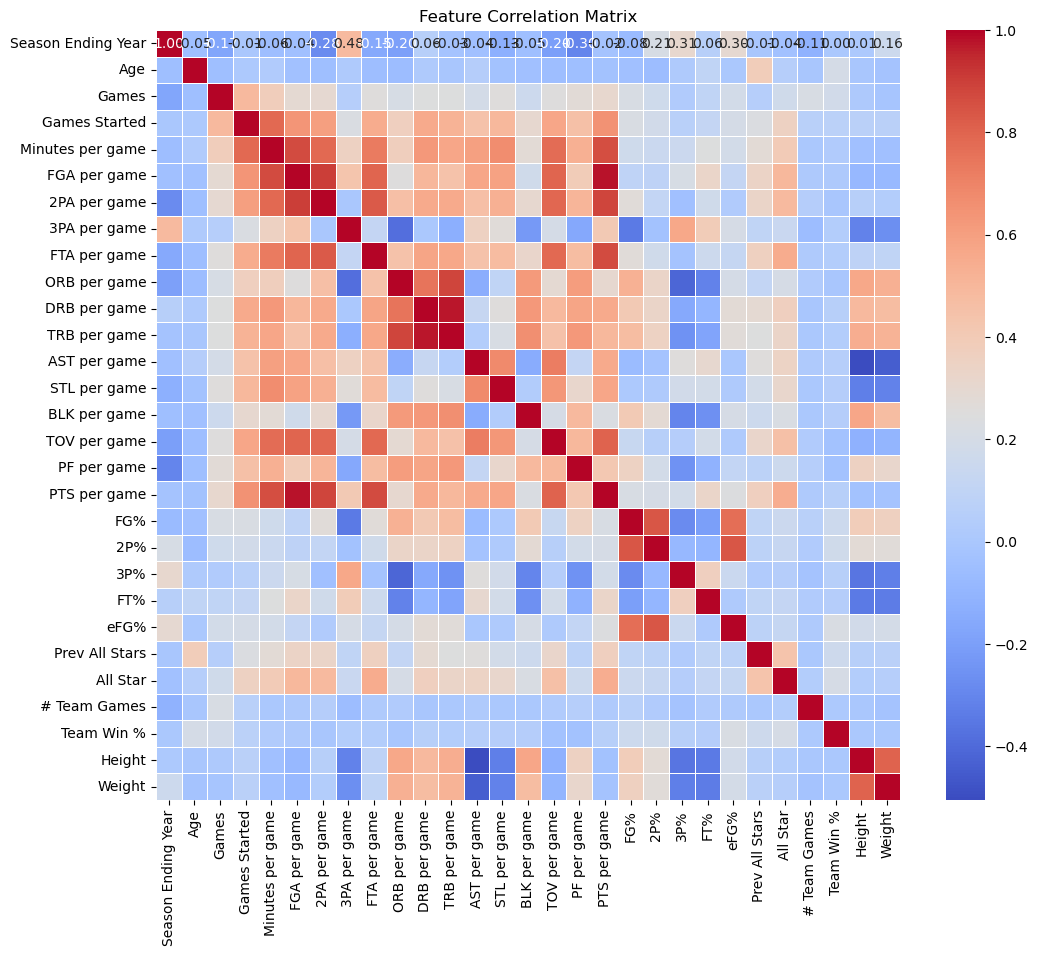

In [6]:

plt.figure(figsize=(12, 10))
# Calculate correlations
corr = df.select_dtypes(include=[np.number]).corr()

# Create the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()